<hr/>

# Foundations of Reinforcement Learning

<hr/>

<h1><font color="darkblue">Lab 1: Intro to Python and two problems on probability</font></h1>



##  Content
1. Jupyter and Jupyterhub
2. Python basic
3. Library installation
4. Lab Problems

### 1. Jupyter and Jupyterhub
#### 1.1 Jupyter

Jupyter is an open-source web application that allows you to create and share documents that contain live code, equations, visualizations and narrative text, (see https://jupyter.org/). To naviagate through Jupyter devalopment environment, see [Notebook Basic](https://github.com/ipython/ipython-in-depth/blob/7e5ce96cc9251083979efdfc393425f1229a4a68/examples/Notebook/Notebook%20Basics.ipynb).

#### 1.2 [Optional] Install Jupyter on your computer
If you prefer to have Jupyter on your computer and run codes offline (e.g. you don't have a stable internet connection), try<br>
[Install Python](https://www.python.org/downloads/) <br>
[Install Anaconda](https://www.anaconda.com/distribution/#download-section)

### 2. Python basic
Python is the programming language we use for this course. If Python seems unfamiliar to you, [Python tutorial](https://cs231n.github.io/python-numpy-tutorial/) may give you a quick start.

### 3 Library Installation
You can add libraries to the Jupyter/Jupyterhub devalopment environment by the following steps:

#### Step 1. Call pip to install
Run the following code

In [1]:
!pip install numpy
!pip install matplotlib

#### Step 2. Add system path (needed only for the first time you add library)
Run the following code

In [2]:
import sys
sys.path.append('FILL IN the installed librarys file directory')
# If you don't know the file directory:
#   Run step 1 again you might see the file directory
#   For the course Jupyterhub it should be /home/**FILL IN YOUR USER NAME**/.local/lib/python3.6/site-packages

### 4. Lab Problems

In [3]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
# import useful libraries

### Problem 1

Given the following mixture of two Gaussians,

$\displaystyle \qquad f(x) = \frac{4}{5\sqrt{2\pi}} \exp\left(-\frac{x^2}{2}\right) + \frac{1}{10\sqrt{2\pi}} \exp\left(-\frac{(x-3)^2}{8}\right)$,


1. Plot the distribution function $f(x)$; (1 pts)
2. Calculate the mean and variance of the given mixture of two Gaussians; (2 pts)
3. Sample 1000000 values from the given mixture of two Gaussians; (3 pts)
4. Plot a distribution histogram of your sampled values. (3 pts)
5. Show the mean and variance of your sampled values. (1 pts)

Total of 10 points


In [4]:
# Define the mixture of two Gaussians
def f(x):
    term1 = (4/(5 * np.sqrt(2 * np.pi)))* np.exp(-0.5 * x**2)
    term2 = (1/(10 * np.sqrt(2 * np.pi))) * np.exp(-(x - 3)**2 / 8)
    return term1 + term2


#### 1.

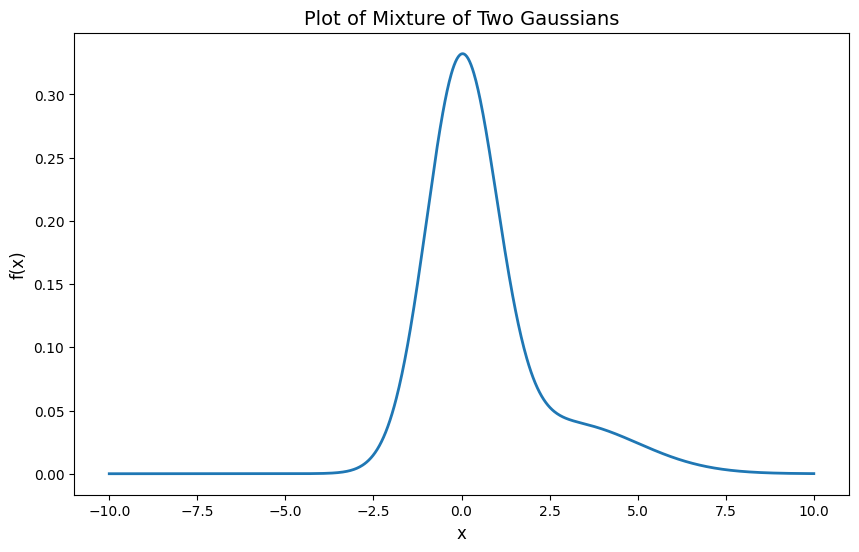

In [5]:
# 1. Plot the distribution function f(x)
x = np.linspace(-10, 10, 1000)
y = f(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, linewidth=2)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('Plot of Mixture of Two Gaussians', fontsize=14)
plt.show()

#### 2.



In [6]:
#2. Calculate the mean and variance of the given mixture of two Gaussians
w1=4/5
mu1=0
sigma1=1
var1=sigma1**2
w2=1/5
mu2=3
sigma2=2
var2=sigma2**2

#E[x]=w1*mu1+w2*mu2
mean=w1*mu1+w2*mu2

#Var(x)=w1*var1+w2*var2+w1*w2*(mu1-mu2)^2
variance=w1*var1+w2*var2+w1*w2*(mu1-mu2)**2

print(f"Mixture Mean (E[X]): {mean:.3f}")
print(f"Mixture Variance (Var[X]): {variance:.3f}")

Mixture Mean (E[X]): 0.600
Mixture Variance (Var[X]): 3.040


#### 3.

In [7]:
#3. Sample 1000000 values from the given mixture of two Gaussians

np.random.seed(260129)
n_samples = 1000000

component = np.random.choice([1, 2], size=n_samples, p=[w1, w2])

samples = np.zeros(n_samples)
samples[component == 1] = np.random.normal(mu1, sigma1, np.sum(component == 1))
samples[component == 2] = np.random.normal(mu2, sigma2, np.sum(component == 2))

print(samples)

[ 2.44475339  0.91128481  0.09168253 ... -1.72373304  0.56819744
 -0.75265809]


#### 4.

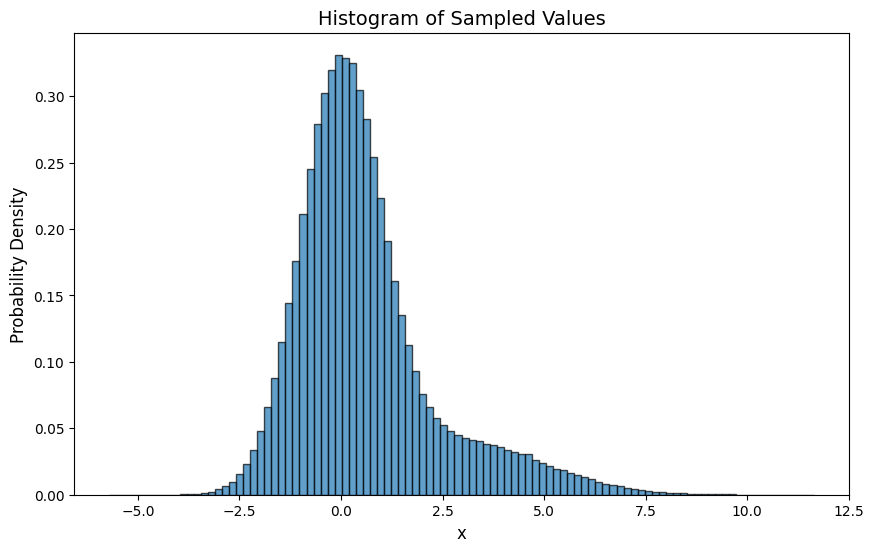

In [8]:
#4. Plot a distribution histogram of your sampled values

plt.figure(figsize=(10, 6))

# Plot histogram of sampled values
plt.hist(samples, bins=100, density=True, alpha=0.7,edgecolor='black')

plt.xlabel('x', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Histogram of Sampled Values', fontsize=14)
plt.show()


#### 5.

In [9]:
#5. Show the mean and variance of your sampled values
sample_mean=np.mean(samples)
sample_variance=np.var(samples)

print(f"Sample Mean (E[X]): {sample_mean:.6f}")
print(f"Sample Variance (Var[X]): {sample_variance:.6f}")

Sample Mean (E[X]): 0.598177
Sample Variance (Var[X]): 3.034716


### Problem 2 [Monty Hall Problem](https://en.wikipedia.org/wiki/Monty_Hall_problem)

#### "Suppose you're on a game show, and you're given the choice of three doors: Behind one door is a car; behind the others, goats. You pick a door, say No. 1, and the host, who knows what's behind the other doors, opens another door, say No. 3, which has a goat. He then says to you, 'Do you want to pick door No. 2?' Is it to your advantage to take the switch?"
Note that we assume the host knows which door the car is behind and will not reveal the location of the car until after the contestant has had the opportunity to switch doors. Say you get reward = 1 for winning the car and reward = 0 otherwise, run this game 1000 times and
1. Plot your average rewards at each time if you always switch; (5 pts)
2. Plot your average rewards at each time if you never switch. (5 pts)


Total of 10 points

#### 1.

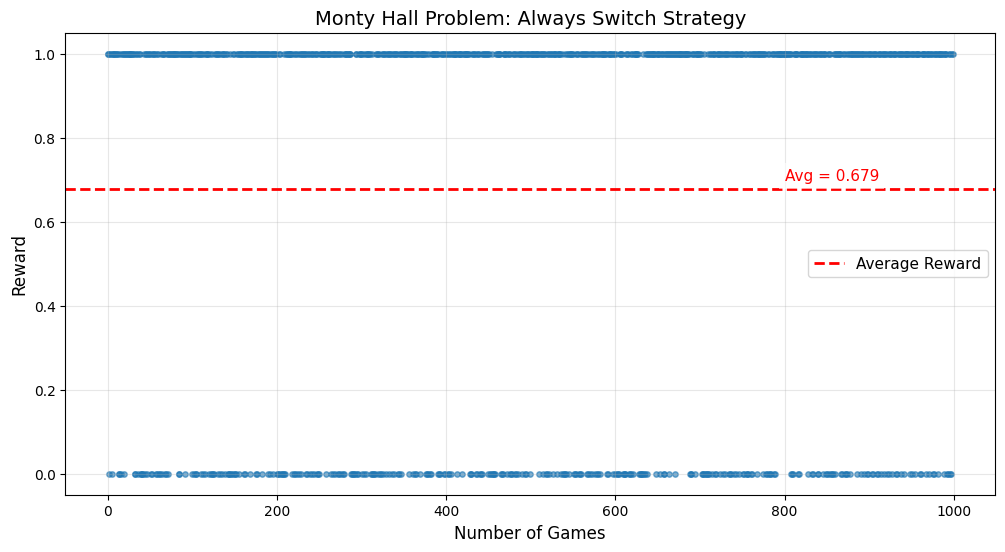

In [10]:
# 1. Always Switch Strategy

np.random.seed(260130)
num_games = 1000
door_num=[1,2,3]
rewards_switch = []

for game in range(num_games):

    car_position = np.random.randint(1, 4)
    initial_choice = np.random.randint(1, 4)

    available_doors = [i for i in door_num if i != initial_choice and i != car_position]
    host_opens = np.random.choice(available_doors)

    remaining_doors = [i for i in door_num if i != initial_choice and i != host_opens]
    final_choice = remaining_doors[0]

    if final_choice == car_position:
        rewards_switch.append(1)
    else:
        rewards_switch.append(0)

    avg_rewards_switch = np.mean(rewards_switch)

plt.figure(figsize=(12, 6))
plt.scatter(np.arange(num_games), rewards_switch, s=15, alpha=0.6)
plt.xlabel('Number of Games', fontsize=12)
plt.ylabel('Reward', fontsize=12)
plt.title('Monty Hall Problem: Always Switch Strategy', fontsize=14)
plt.axhline(y=avg_rewards_switch, color='r', linestyle='--', linewidth=2, label='Average Reward')

plt.text(num_games * 0.8, avg_rewards_switch + 0.02, f"Avg = {avg_rewards_switch:.3f}",
         color='r', fontsize=11, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()


#### 2.

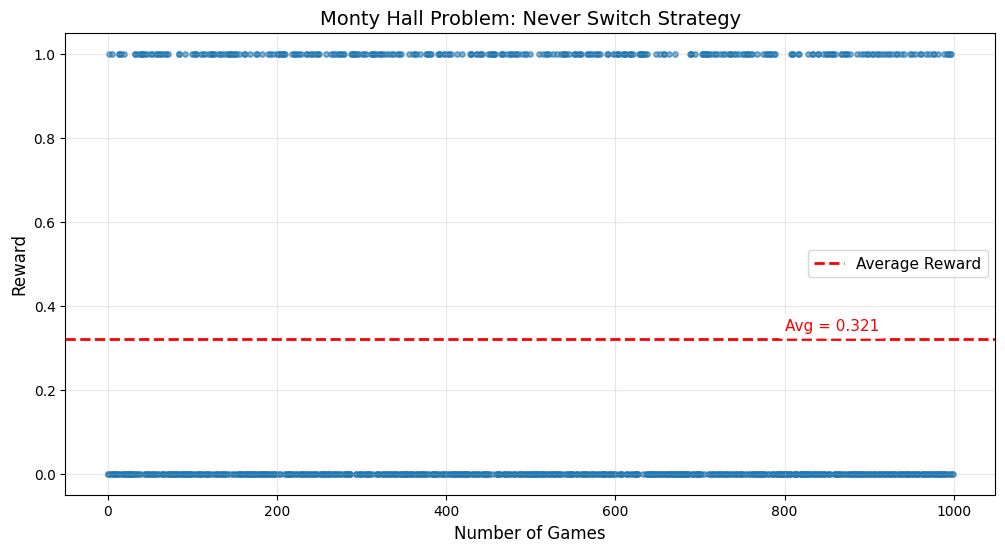

In [11]:
# 2. Never Switch Strategy

np.random.seed(260130)
num_games = 1000
door_num=[1,2,3]
rewards_noswitch = []

for game in range(num_games):

    car_position = np.random.randint(1, 4)
    initial_choice = np.random.randint(1, 4)

    available_doors = [i for i in door_num if i != initial_choice and i != car_position]
    host_opens = np.random.choice(available_doors)

    remaining_doors = [i for i in door_num if i != initial_choice and i != host_opens]
    final_choice = initial_choice

    if final_choice == car_position:
        rewards_noswitch.append(1)
    else:
        rewards_noswitch.append(0)

    avg_rewards_noswitch = np.mean(rewards_noswitch)

plt.figure(figsize=(12, 6))
plt.scatter(np.arange(num_games), rewards_noswitch, s=15, alpha=0.6)
plt.xlabel('Number of Games', fontsize=12)
plt.ylabel('Reward', fontsize=12)
plt.title('Monty Hall Problem: Never Switch Strategy', fontsize=14)
plt.axhline(y=avg_rewards_noswitch, color='r', linestyle='--', linewidth=2, label='Average Reward')

plt.text(num_games * 0.8, avg_rewards_noswitch + 0.02, f"Avg = {avg_rewards_noswitch:.3f}",
         color='r', fontsize=11, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()
